# Example 5: a neural ODE as a Model Exchange FMU

Examples 1-4 export a network that computes its output *directly* from its
inputs. This example is different: the network we train and export,
`f_theta(t, x)`, is only the **right-hand side of an ODE**,
`dx/dt = f_theta(t, x)`. ONNX2FMU wraps it as a **Model Exchange** FMU, and
it is the *FMI importer's own solver* (e.g. CVode) that integrates it at
simulation time -- ONNX2FMU never runs an internal solver over it.

The training target is a forced Van der Pol oscillator:

```
dx0/dt = x1
dx1/dt = (1 - x0^2) * x1 - x0 + A * sin(omega * t)
```

which is why the exported network also takes the simulation time `t` as an
input, declared with `"time": true` in the model description -- the forcing
term makes the system non-autonomous. We train with
[torchdiffeq](https://github.com/rtqichen/torchdiffeq)'s `odeint`, which
integrates the candidate right-hand side during training and backpropagates
through the ODE solve -- the same "neural ODE" recipe from Chen et al.
(2018).

In [1]:
import json
import numpy as np
import torch
from torch import nn
import onnx
import pandas as pd
from torchdiffeq import odeint

torch.manual_seed(0)
np.random.seed(0)

## True dynamics and a reference integrator

Used both to generate training trajectories and, later, to check the compiled FMU.

In [2]:
A, OMEGA = 0.5, 1.0


def true_derivative(t: float, x: np.ndarray) -> np.ndarray:
    return np.array([
        x[1],
        (1.0 - x[0] ** 2) * x[1] - x[0] + A * np.sin(OMEGA * t),
    ])


def rk4_trajectory(x0, t_eval, dt=1e-3):
    """Reference trajectory of the true dynamics, sampled at t_eval."""
    x = np.array(x0, dtype=float)
    t = 0.0
    out = [x.copy()]
    next_idx = 1
    n_steps = int(round(t_eval[-1] / dt))
    for _ in range(n_steps):
        k1 = true_derivative(t, x)
        k2 = true_derivative(t + dt / 2, x + dt / 2 * k1)
        k3 = true_derivative(t + dt / 2, x + dt / 2 * k2)
        k4 = true_derivative(t + dt, x + dt * k3)
        x = x + dt / 6 * (k1 + 2 * k2 + 2 * k3 + k4)
        t += dt
        if next_idx < len(t_eval) and abs(t - t_eval[next_idx]) < dt / 2:
            out.append(x.copy())
            next_idx += 1
    return np.array(out)

## The network

`DerivativeNet` is the module we actually export to ONNX -- it takes the state `x` and time `t` (ONNX2FMU's input order) and returns `dx/dt`. `TorchdiffeqRHS` is a thin wrapper matching the `func(t, y)` signature `torchdiffeq.odeint` expects.

In [3]:
class DerivativeNet(nn.Module):
    """f_theta(x, t) -> dx/dt. This is the module exported to ONNX, with
    inputs in ONNX2FMU's order: state first, time second."""

    def __init__(self, hidden: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, hidden), nn.Tanh(),
            nn.Linear(hidden, hidden), nn.Tanh(),
            nn.Linear(hidden, 2),
        )

    def forward(self, x: torch.Tensor, t: torch.Tensor) -> torch.Tensor:
        if x.dim() > 1:
            t_col = t.reshape(1).expand(x.shape[0], 1)
        else:
            t_col = t.reshape(1)
        return self.net(torch.cat([x, t_col], dim=-1))


class TorchdiffeqRHS(nn.Module):
    """torchdiffeq.odeint calls func(t, y); wrap DerivativeNet to match."""

    def __init__(self, net: DerivativeNet):
        super().__init__()
        self.net = net

    def forward(self, t: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
        return self.net(y, t)

## Training data

16 trajectories from random initial conditions, integrated with the true dynamics over a 10 s horizon -- the same horizon we'll later simulate the FMU over.

In [4]:
def make_training_set(n_trajectories=16, t_span=30.0, n_points=200):
    t_eval = np.linspace(0.0, t_span, n_points)
    x0s = np.random.uniform(low=[-2.5, -2.5], high=[2.5, 2.5],
                            size=(n_trajectories, 2))
    trajectories = np.stack(
        [rk4_trajectory(x0, t_eval) for x0 in x0s], axis=1
    )  # (n_points, n_trajectories, 2)
    return (
        torch.tensor(t_eval, dtype=torch.float32),
        torch.tensor(x0s, dtype=torch.float32),
        torch.tensor(trajectories, dtype=torch.float32),
    )

## Training loop

Each iteration integrates the *candidate* right-hand side with `odeint` over the full training horizon and backpropagates the trajectory error -- this is what makes it a neural ODE rather than a simple regression on the vector field.

In [ ]:
def train(n_iters=10000, lr=1e-2):
    t_eval, x0s, target = make_training_set()
    net = DerivativeNet()
    rhs = TorchdiffeqRHS(net)
    optimizer = torch.optim.Adam(rhs.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=300, gamma=0.5)

    for it in range(n_iters):
        optimizer.zero_grad()
        pred = odeint(rhs, x0s, t_eval, method="rk4",
                      options={"step_size": 0.05})
        loss = torch.mean((pred - target) ** 2)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(rhs.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        if it % 100 == 0 or it == n_iters - 1:
            print(f"iter {it:4d}  loss {loss.item():.6f}  "
                  f"lr {scheduler.get_last_lr()[0]:.5f}")

    return net


net = train()

iter    0  loss 23.805147  lr 0.01000
iter  100  loss 1.167264  lr 0.01000
iter  200  loss 1.423599  lr 0.01000
iter  300  loss 1.151993  lr 0.00500
iter  400  loss 0.826000  lr 0.00500
iter  500  loss 1.044918  lr 0.00500
iter  600  loss 0.467185  lr 0.00250
iter  700  loss 0.575015  lr 0.00250
iter  800  loss 0.432589  lr 0.00250
iter  900  loss 0.475694  lr 0.00125
iter 1000  loss 0.359020  lr 0.00125
iter 1100  loss 0.386288  lr 0.00125
iter 1199  loss 0.376454  lr 0.00063


## Export to ONNX

Only `DerivativeNet` -- the vector field -- is exported. The FMU does **not**
embed a solver; the FMI importer supplies its own when it drives the FMU in
Model Exchange mode.

In [6]:
net.eval()
x_example = torch.tensor([2.0, 0.0])
# ONNX2FMU requires every declared node to have rank >= 1 (a 0-d scalar
# shape is rejected), so "t" must be exported with shape (1,), not as a
# bare scalar tensor.
t_example = torch.tensor([0.0])
torch.onnx.export(
    net, (x_example, t_example), "example5.onnx",
    input_names=["x", "t"],
    output_names=["dx"],
)

onnx_model = onnx.load("example5.onnx")
onnx.checker.check_model(onnx_model)
# Pin the IR version to what the pinned ONNX Runtime release in
# onnx2fmu/CMakeLists.txt actually supports (avoids a load failure if the
# local `onnx` package is newer than the pinned ORT release).
onnx_model.ir_version = 10
onnx_model.graph.doc_string = (
    "Right-hand side of a forced Van der Pol neural ODE, "
    "trained with torchdiffeq."
)
onnx.save(onnx_model, "example5.onnx")

W0816 22:20:56.158000 19744 torch/onnx/_internal/exporter/_registration.py:107] torchvision is not installed. Skipping torchvision::nms


[torch.onnx] Obtain model graph for `DerivativeNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `DerivativeNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...
[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅


## Model description

- `"FMUType": ["ModelExchange", "CoSimulation"]` builds both interfaces.
- The state `"x"` is reclassified by ONNX2FMU as an `output`-causality,
`initial="exact"` variable and **must** declare `"start"` (its initial
condition).
- `"t"` is flagged `"time": true`: ONNX2FMU feeds it the FMI independent
variable on every evaluation instead of generating an FMI variable for it.
- `"dx"` declares `"derivativeOf": "x"`, so ONNX2FMU emits it as a
`local`-causality, `initial="calculated"` variable carrying the FMI
`derivative` attribute.

In [7]:
model_description = {
    "name": "example5",
    "description": (
        "Neural ODE (trained with torchdiffeq) approximating a forced "
        "Van der Pol oscillator. dx/dt = f_theta(t, x); the FMU's own "
        "Model Exchange solver integrates it."
    ),
    "FMIVersion": "3.0",
    "FMUType": ["ModelExchange", "CoSimulation"],
    "inputs": [
        {
            "name": "x",
            "description": "State vector [x0, x1].",
            "labels": ["x0", "x1"],
            "start": [2.0, 0.0],
        },
        {
            "name": "t",
            "description": "Simulation time, fed to the forcing term.",
            "time": True,
        },
    ],
    "outputs": [
        {
            "name": "dx",
            "description": "dx/dt, the learned state derivative.",
            "labels": ["der_x0", "der_x1"],
            "derivativeOf": "x",
        },
    ],
}

with open("example5Description.json", "w", encoding="utf-8") as f:
    json.dump(model_description, f, indent=4)

## Reference trajectory

The *true* dynamics, sampled the same way `fmpy` will sample the compiled FMU -- used to sanity-check the trained network end-to-end (see the project README's Model Exchange section for how to build and simulate the FMU with `onnx2fmu`/`fmpy`).

In [8]:
x0, t_span, n_points = (2.0, 0.0), 10.0, 21
t_eval = np.linspace(0.0, t_span, n_points)
trajectory = rk4_trajectory(list(x0), t_eval)

df = pd.DataFrame(trajectory, columns=["x_0", "x_1"])
df["time"] = t_eval
df.set_index("time", inplace=True)
df.to_csv("Example5_ref.csv")
df

,x_0,x_1
time,,
0.0,2.000000,0.000000
0.5,1.845322,-0.492499
1.0,1.559944,-0.634182
1.5,1.211264,-0.770726
2.0,0.769216,-1.029119
2.5,0.136670,-1.555749
3.0,-0.799224,-2.072194
3.5,-1.638764,-1.008957
4.0,-1.821329,0.102224


## Build and simulate the FMU

Build the Model Exchange/Co-Simulation FMU from the exported ONNX model and
run it through `fmpy`. Passing `fmi_type="ModelExchange"` makes `fmpy` drive
the FMU with its own solver (`CVode` by default) via
`getContinuousStates`/`setContinuousStates`/`getDerivatives` -- exactly the
mechanism described in the README's Model Exchange section -- rather than
stepping the network internally as ONNX2FMU's Co-Simulation interface would.
The state `x` is exposed as `x_0`/`x_1` and integrated by the solver; no
input needs to be supplied since the FMU already declares `x`'s initial
condition and the time input via `start`/`time: true`.

In [9]:
from onnx2fmu.app import build

build(
    model_path="example5.onnx",
    model_description_path="example5Description.json",
    target_folder="temp",
    destination="example5.fmu",
)

2026-08-16 22:20:57.190 | INFO     | onnx2fmu.app:compile:296 - Call cmake -S temp -B temp/build -D MODEL_NAME=example5 -D FMI_VERSION=3
2026-08-16 22:20:58.546 | INFO     | onnx2fmu.app:compile:298 - CMake build cmake --build temp/build --config Release


In [12]:
import matplotlib.pyplot as plt
from fmpy import simulate_fmu

results = simulate_fmu(
    "example5.fmu",
    fmi_type="ModelExchange",
    solver="CVode",
    start_time=t_eval[0],
    stop_time=t_eval[-1],
    output_interval=t_eval[1] - t_eval[0],
    output=["x_0", "x_1"],
    validate=True,
)

fmu_df = pd.DataFrame(results).set_index("time")
fmu_df

,x_0,x_1
time,,
0.0,2.000000,0.000000
0.5,1.803040,-0.618198
1.0,1.520246,-1.212007
1.5,1.201878,-1.649946
2.0,0.837628,-1.910993
2.5,0.376884,-1.988703
3.0,-0.223196,-1.922634
3.5,-0.933911,-1.676533
4.0,-1.590092,-1.191147


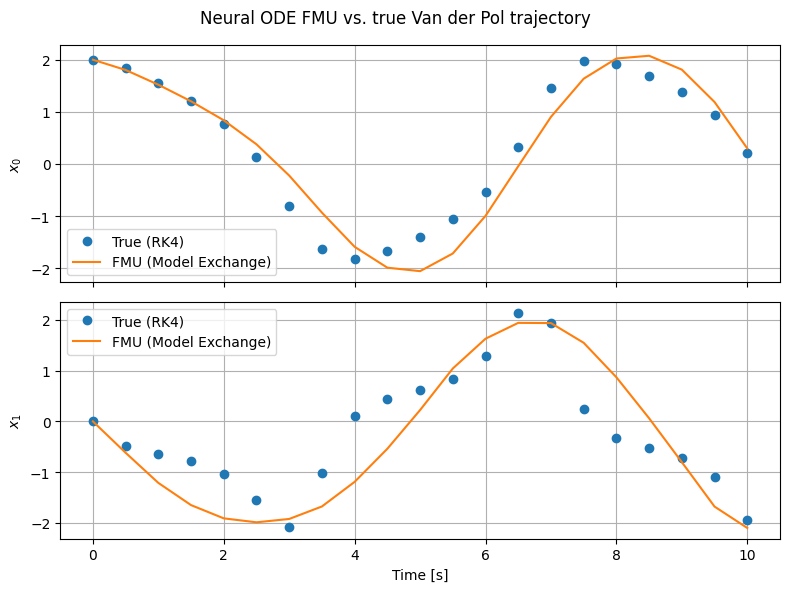

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

for ax, col, label in zip(axes, ["x_0", "x_1"], ["$x_0$", "$x_1$"]):
    ax.plot(df.index, df[col], "o", label="True (RK4)")
    ax.plot(fmu_df.index, fmu_df[col], "-", label="FMU (Model Exchange)")
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True)

axes[-1].set_xlabel("Time [s]")
fig.suptitle("Neural ODE FMU vs. true Van der Pol trajectory")
plt.tight_layout()
plt.show()